In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
import pandas as pd

fPath = r"C:\Users\oluwa\participant_extracted.csv"

df = pd.read_csv(fPath)
df.head(20)

,subject_id,hadm_id,gender,age_at_admission,admission_type,discharge_location,admittime,dischtime,next_admittime,prior_admission_count,...,antidiabetic_drug_count,rx_insulin,rx_metformin,rx_sulfonylurea,rx_dpp4_inhibitor,ckd_flag,chf_flag,htn_flag,neuropathy_flag,infection_flag
0,18004595,29622193,M,67,DIRECT EMER.,HOME,9/03/2123 3:59,12/03/2123 18:09,NaN,5,...,2,1,0,0,0,1,0,0,0,0
1,18004660,20175273,M,66,EW EMER.,ASSISTED LIVING,5/03/2121 8:21,7/03/2121 10:15,NaN,2,...,1,1,0,0,0,0,0,1,0,0
2,18005279,20998850,F,92,URGENT,SKILLED NURSING FACILITY,13/09/2166 15:00,21/09/2166 14:25,NaN,1,...,1,1,0,0,0,0,1,1,0,0
3,18005486,28915994,F,67,SURGICAL SAME DAY ADMISSION,REHAB,17/08/2182 0:00,1/09/2182 17:40,19/01/2183 20:21,0,...,1,1,0,0,0,1,1,0,0,0
4,18006842,24626114,M,47,EW EMER.,HOME,21/06/2182 22:22,27/06/2182 17:00,26/09/2182 18:09,4,...,1,1,0,0,0,1,1,0,0,0
5,18006842,28395687,M,48,OBSERVATION ADMIT,HOME,19/09/2183 4:52,28/09/2183 16:00,1/01/2184 16:18,6,...,1,1,0,0,0,1,1,0,0,0
6,18006842,21423997,M,53,DIRECT EMER.,HOME HEALTH CARE,27/01/2188 11:52,4/02/2188 15:30,21/02/2188 22:04,12,...,1,1,0,0,0,1,1,0,0,0
7,18006842,20982739,M,53,OBSERVATION ADMIT,ACUTE HOSPITAL,21/02/2188 22:04,24/02/2188 21:00,NaN,13,...,1,1,0,0,0,1,1,0,0,0
8,18007632,23251261,M,52,SURGICAL SAME DAY ADMISSION,HOME HEALTH CARE,21/10/2111 0:00,30/10/2111 15:45,NaN,1,...,4,1,0,1,0,1,0,0,0,0
9,18007743,24157711,M,86,EW EMER.,HOME,18/10/2131 11:02,21/10/2131 14:15,1/04/2135 12:19,2,...,2,1,1,1,0,0,1,0,0,0


In [27]:
import pandas as pd

# Load necessary columns from MIMIC-Cohort admissions
df = pd.read_csv(fPath, usecols=["subject_id", "hadm_id"])

# Count admissions per patient
admission_counts = (
    df.groupby("subject_id")["hadm_id"]
      .nunique()                                 # counts unique admissions  
      .reset_index(name="T_hosp_visits")
      .sort_values(by="T_hosp_visits", ascending=False)
)
print("Patients' Total Number of Hospital Visits - MIMIC-Cohort")
print("=====================================================")
print(admission_counts.head(20))

Patients' Total Number of Hospital Visits - MIMIC-Cohort
       subject_id  T_hosp_visits
7000     11582633            100
33313    17517983             93
2515     10577647             89
6106     11389314             82
5719     11296936             75
16213    13658097             70
38331    18655830             70
38409    18676703             70
11301    12547294             70
39426    18902344             68
2523     10580201             65
4469     11021643             63
30192    16809525             62
7574     11714071             62
34222    17718683             62
35183    17937834             62
43011    19713100             59
7791     11761621             56
28530    16439884             56
521      10123949             56


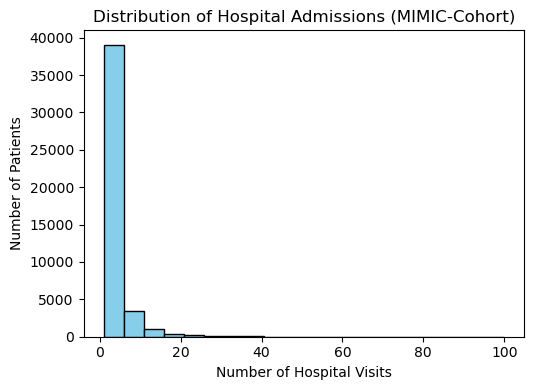


APA-Style Summary Table
                    Measure MIMIC-Cohort Value
         Total Patients (N)              44272
  Mean Hospital Visits (SD)        2.89 (4.09)
30-Day Readmission Rate (%)             25.58%

Preview of MIMIC-Cohort Modeling Dataset:
    subject_id  T_hosp_visits  readmitted_30days
0     10000635              2              False
1     10000980              7              False
2     10001176              1              False
3     10001843              1              False
4     10001877              2              False
5     10002013             18               True
6     10002221              5               True
7     10002443              1              False
8     10002495              1              False
9     10002976              3               True
10    10003299              4               True
11    10004322              4              False
12    10005236              2              False
13    10005368              1              False
14    100

In [37]:
# Load only required columns for efficiency for MIMIC-Cohort
from datetime import datetime

df = pd.read_csv(
    fPath,
    usecols=["subject_id", "hadm_id", "admittime", "dischtime"] # Corrected usecols
)

# 2️⃣ PREPARE TIME VARIABLES

# Convert to datetime format for MIMIC-Cohort
df["admittime"] = pd.to_datetime(df["admittime"], format="%d/%m/%Y %H:%M") # Corrected DataFrame reference
df["dischtime"] = pd.to_datetime(df["dischtime"], format="%d/%m/%Y %H:%M") # Corrected DataFrame reference

# Sort by patient and admission time
df = df.sort_values(["subject_id", "admittime"])

# -------------------------------------------------------
# 3️⃣ CALCULATE TOTAL ADMISSIONS PER PATIENT
# -------------------------------------------------------

admission_counts = (
    df.groupby("subject_id")["hadm_id"] # Corrected DataFrame reference
      .nunique()
      .reset_index(name="T_hosp_visits")
)

# 4️⃣ CALCULATE 30-DAY READMISSION
# -------------------------------------------------------
# Get next admission per patient for MIMIC-Cohort
df["next_admittime"] = df.groupby("subject_id")["admittime"].shift(-1) # Corrected typo 'amittime' to 'admittime'

# Calculate difference in days between discharge and next admission for MIMIC-Cohort
df["days_to_readmit"] = (
    df["next_admittime"] - df["dischtime"]
).dt.days

# Flag 30-day readmission for MIMIC-Cohort
df["readmitted_30days"] = df["days_to_readmit"] <= 30

# Patient-level readmission indicator for MIMIC-Cohort
readmission_summary = (
    df.groupby("subject_id")["readmitted_30days"]
      .any()
      .reset_index()
)

# 5️⃣ MERGE ADMISSION + READMISSION RESULTS
# -------------------------------------------------------

final_df = admission_counts.merge(
    readmission_summary,
    on="subject_id",
    how="left"
)

# Replace missing values with False

final_df["readmitted_30days"] = final_df["readmitted_30days"].fillna(False)

# -------------------------------------------------------
# 6️⃣ VISUALIZATION: ADMISSION DISTRIBUTION
# -------------------------------------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1) # Subplot for MIMIC-Cohort
plt.hist(final_df["T_hosp_visits"], bins=20, color='skyblue', edgecolor='black')
plt.xlabel("Number of Hospital Visits")
plt.ylabel("Number of Patients")
plt.title("Distribution of Hospital Admissions (MIMIC-Cohort)")

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# 7️⃣ APA-STYLE SUMMARY TABLE
# -------------------------------------------------------

total_patients_mimic4 = final_df.shape[0]

mean_visits_mimic4 = final_df["T_hosp_visits"].mean()

sd_visits_mimic4 = final_df["T_hosp_visits"].std()

readmission_rate_mimic4 = final_df["readmitted_30days"].mean() * 100

apa_table = pd.DataFrame({
    "Measure": [
        "Total Patients (N)",
        "Mean Hospital Visits (SD)",
        "30-Day Readmission Rate (%)"
    ],
    
    "MIMIC-Cohort Value": [
        total_patients_mimic4,
        f"{mean_visits_mimic4:.2f} ({sd_visits_mimic4:.2f})",
        f"{readmission_rate_mimic4:.2f}%"
    ]
})

print("\nAPA-Style Summary Table")
print(apa_table.to_string(index=False))

# -------------------------------------------------------
# 8️⃣ PREVIEW FINAL DATASET (FOR MODELING)
# -------------------------------------------------------

print("\nPreview of MIMIC-Cohort Modeling Dataset:")
print(final_df.head(20))

# Saving the final results to a CSV file
final_df.to_csv("patient_admission_summary_mimiccohort.csv", index=False)